# MLDoctor - Case1
For a high-end grooming application, the engineering team developed a model to discern clean-shaven faces. During the “Lab Phase,” the model performed exceptionally well, trained and validated on studio-quality images. It achieved a near-perfect accuracy on the Internal test Set. However, once deployed in a mobile application, the model’s accuracy significantly decreased. Users have reported that the model frequently fails. What happened during the transition from the “Studio” to the “Mobile App”? Please elaborate on the identified problem, explain how it was identified, and provide a recommended solution. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import pandas as pd
import seaborn as sns

#import torch which has many of the functions to build deep learning models and to train them
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

#import torchvision, which was lots of functions for loading and working with image data
import torchvision
import torchvision.transforms as transforms

#this is a nice progress bar representation that will be good to measure progress during training
import tqdm
import copy
import random

# fix seed for reproducibility
torch.manual_seed(0)
np.random.seed(0)
random.seed(0)

# setup device
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu') #this line checks if we have a GPU available
print(f"Using device: {device}")

Using device: cuda:0


## Data

In [2]:
# Load the full training dataset first (without transforms for now)
test_internal_dataset = torchvision.datasets.ImageFolder('Case1Dataset/test_internal')
print(f'Internal test dataset size: {len(test_internal_dataset)}')
test_external_dataset = torchvision.datasets.ImageFolder('Case1Dataset/test_external')
print(f'External test dataset size: {len(test_external_dataset)}')

# Imnagenet preprocessing
imagenet_means = (0.485, 0.456, 0.406)
imagenet_stds = (0.229, 0.224, 0.225)

# preprocessing transform
transform = transforms.Compose(
    [transforms.ToTensor(),
    transforms.Resize((224, 224)), 
    transforms.Normalize(imagenet_means, imagenet_stds)])


# Apply transforms to the datasets
test_internal_dataset.transform = transform
test_external_dataset.transform = transform

# create dataloaders for train, val, test datasets
batch_size = 16
test_internal_loader = torch.utils.data.DataLoader(test_internal_dataset, batch_size=batch_size, shuffle=False, num_workers = 0)
test_external_loader = torch.utils.data.DataLoader(test_external_dataset, batch_size=batch_size, shuffle=False, num_workers = 0)

Internal test dataset size: 844
External test dataset size: 748


## Developed Model

In [3]:
def setup_model(model, num_classes, freeze_backbone = False):
    
    #### Adapt the architecture for the new number of classes.
    in_features = model.fc.in_features
    model.fc = nn.Linear(model.fc.in_features, num_classes)

    #### If necessary, freeze any weights.
    if freeze_backbone: 
        for param in model.parameters():
            param.requires_grad = False
        
        # Unfreeze the parameters of the last fully connected layer
        for param in model.fc.parameters():
            param.requires_grad = True

    return model

# setup the model
backbone = torchvision.models.resnet18(weights=torchvision.models.ResNet18_Weights.DEFAULT)
resnet_frozen = setup_model(backbone, 2, False)

# Load the developed model
resnet_frozen.load_state_dict(torch.load("resnet_frozen_best_case1.pth"))
resnet_frozen.eval()
resnet_frozen = resnet_frozen.to(device)
print(resnet_frozen)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_sta

## Evaluation

In [4]:
# Collect predictions and ground truth labels
all_predictions = {'internal': [], 'external': []}
all_labels = {'internal': [], 'external': []}

# compute predictions
with torch.no_grad():
    for split, dataloader in zip(['internal', 'external'], [test_internal_loader, test_external_loader]):
        for data in tqdm.tqdm(dataloader, desc=f'Evaluating on {split} set'):
            inputs, labels = data
            inputs = inputs.to(device)
            labels = labels.to(device)

            outputs = resnet_frozen(inputs)
            probs = torch.softmax(outputs, dim=1)

            all_predictions[split].append(probs.cpu().numpy())
            all_labels[split].append(labels.cpu().numpy())
print("Evaluation complete.")

for split in ['internal', 'external']:
    all_predictions[split] = np.concatenate(all_predictions[split], axis=0)
    all_labels[split] = np.concatenate(all_labels[split], axis=0)
    predicted_classes = np.argmax(all_predictions[split], axis=1)
    accuracy = (predicted_classes == all_labels[split]).mean()
    print(f"{split} set - Accuracy: {accuracy:.3f}")

Evaluating on external set: 100%|██████████| 47/47 [00:03<00:00, 14.64it/s]

Evaluation complete.
internal set - Accuracy: 0.937
external set - Accuracy: 0.623


Class mapping: {'negative': 0, 'positive': 1}


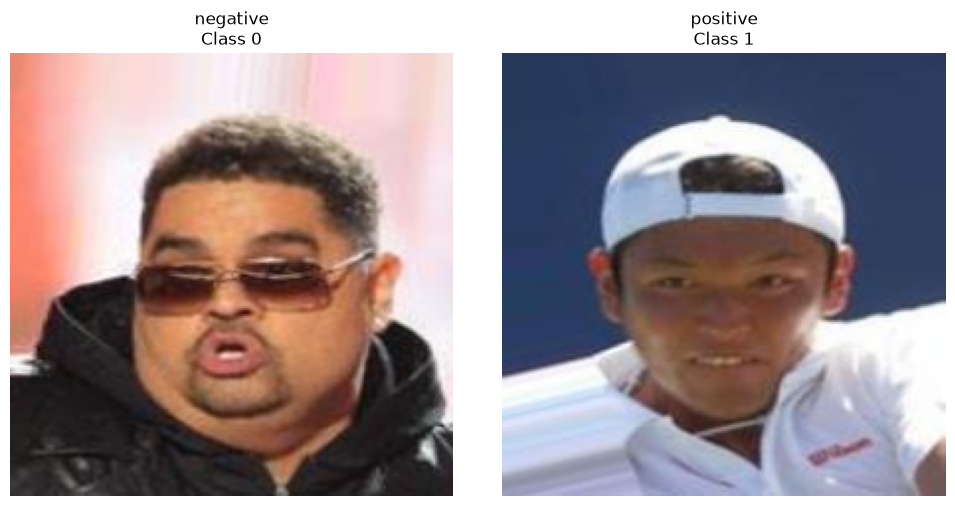

In [5]:
# Check class names and corresponding indices
print("Class mapping:", test_internal_dataset.class_to_idx)

# Display one sample image from each class
fig, axes = plt.subplots(1, len(test_internal_dataset.classes), figsize=(10, 5))

for class_idx, class_name in enumerate(test_internal_dataset.classes):
    
    # Find the first sample belonging to this class
    sample_idx = test_internal_dataset.targets.index(class_idx)
    image, label = test_internal_dataset[sample_idx]

    # Denormalise for display
    image = image.cpu().numpy().transpose(1, 2, 0)
    image = image * np.array(imagenet_stds) + np.array(imagenet_means)
    image = np.clip(image, 0, 1)

    axes[class_idx].imshow(image)
    axes[class_idx].set_title(f"{class_name}\nClass {class_idx}")
    axes[class_idx].axis("off")

plt.tight_layout()
plt.show()


===== INTERNAL SET =====
Accuracy : 0.937
Precision: 0.915
Recall   : 0.965
F1-score : 0.939


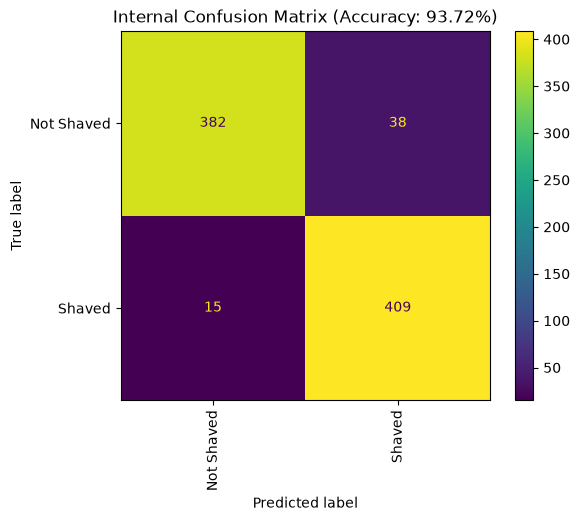


===== EXTERNAL SET =====
Accuracy : 0.623
Precision: 0.574
Recall   : 0.989
F1-score : 0.726


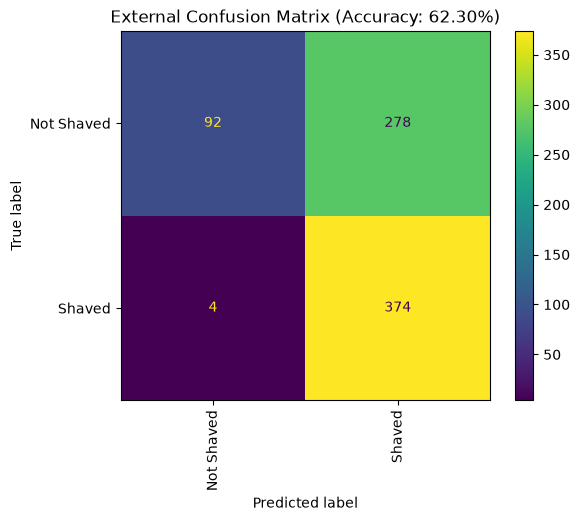

In [6]:
from sklearn.metrics import ConfusionMatrixDisplay

# Compute TP, FP, TN, FN for binary classification
def confusion_matrix_counts(labels, probs, threshold=0.5):
    
    labels = labels.astype(bool)
    probs = probs.astype(float)

    # Convert probabilities to binary predictions
    preds = probs >= threshold

    tp = np.sum(preds & labels)
    fp = np.sum(preds & ~labels)
    tn = np.sum(~preds & ~labels)
    fn = np.sum(~preds & labels)

    return tp, fp, tn, fn


# Compute precision, recall and F1-score
def compute_metrics(labels, probs, threshold=0.5):
    
    tp, fp, tn, fn = confusion_matrix_counts(
        labels,
        probs,
        threshold=threshold
    )

    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = (
        2 * precision * recall / (precision + recall)
        if (precision + recall) > 0
        else 0
    )

    return precision, recall, f1


# Evaluate the model on the internal and external test sets
threshold = 0.5

for split in ['internal', 'external']:

    # Ground-truth labels: 0 = Not Shaved, 1 = Shaved
    labels = all_labels[split]

    # Predicted probability for the positive class (Shaved)
    probs_shaved = all_predictions[split][:, 1]

    # Convert probabilities to predicted classes
    preds = probs_shaved >= threshold

    # Compute evaluation metrics
    accuracy = (preds == labels.astype(bool)).mean()
    precision, recall, f1 = compute_metrics(
        labels,
        probs_shaved,
        threshold=threshold
    )

    # Print results
    print(f"\n===== {split.upper()} SET =====")
    print(f"Accuracy : {accuracy:.3f}")
    print(f"Precision: {precision:.3f}")
    print(f"Recall   : {recall:.3f}")
    print(f"F1-score : {f1:.3f}")

    # Plot confusion matrix
    ConfusionMatrixDisplay.from_predictions(
        labels,
        preds,
        display_labels=['Not Shaved', 'Shaved'],
        xticks_rotation='vertical'
    )

    plt.title(
        f'{split.capitalize()} Confusion Matrix '
        f'(Accuracy: {accuracy * 100:.2f}%)'
    )

    plt.show()

False positives increased substantially from 38 in the internal test set to 278 in the external test set, indicating that many non-shaved faces were incorrectly classified as shaved.  
Consequently, precision for the shaved class decreased significantly.  

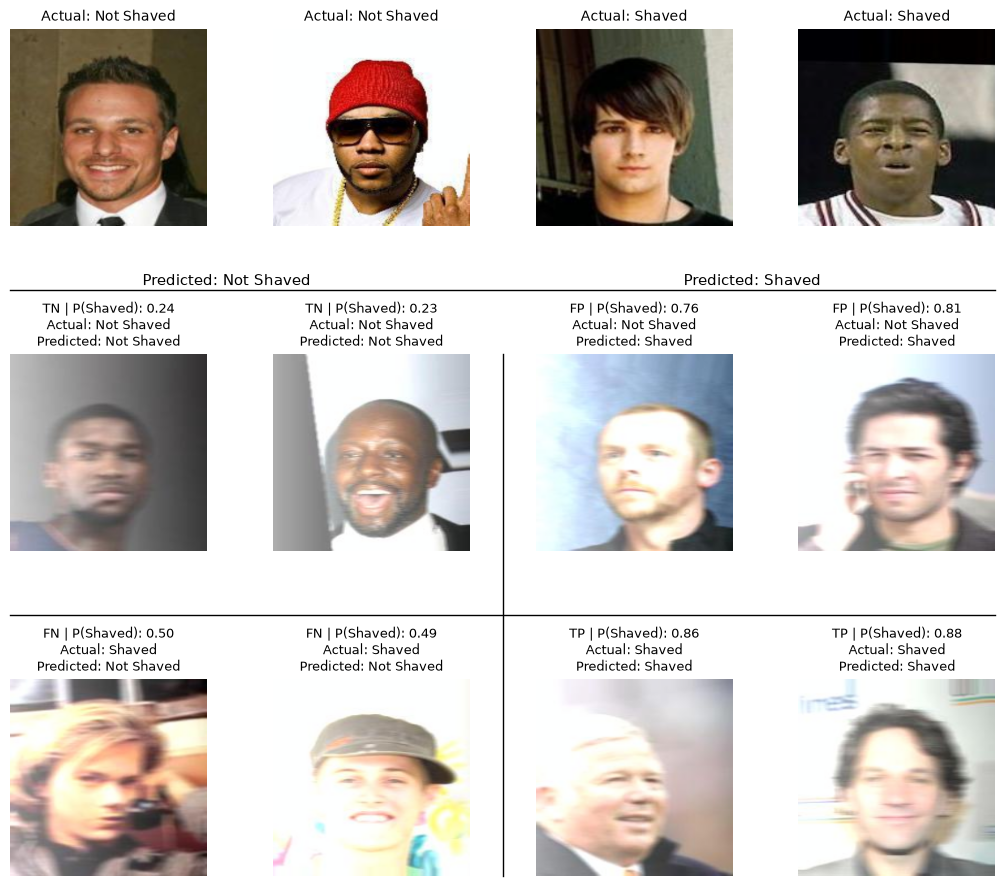

In [7]:
# Use the external predictions already computed above
labels = all_labels['external']
probs_shaved = all_predictions['external'][:,1]
preds = probs_shaved >= threshold

# Identify external samples by confusion matrix outcome
tn_indices = np.where((labels == 0) & (preds == 0))[0]
fp_indices = np.where((labels == 0) & (preds == 1))[0]
fn_indices = np.where((labels == 1) & (preds == 0))[0]
tp_indices = np.where((labels == 1) & (preds == 1))[0]

# Identify internal samples by actual class
internal_labels = all_labels['internal']
internal_not_shaved = np.where(internal_labels == 0)[0]
internal_shaved = np.where(internal_labels == 1)[0]

# Select two samples from each group
np.random.seed(0)
internal_indices = np.concatenate([
    np.random.choice(internal_not_shaved,2,replace=False),
    np.random.choice(internal_shaved,2,replace=False)
])
external_indices = [
    np.random.choice(tn_indices,2,replace=False),
    np.random.choice(fp_indices,2,replace=False),
    np.random.choice(fn_indices,2,replace=False),
    np.random.choice(tp_indices,2,replace=False)
]

# Denormalize images for visualization
def denormalize_image(image):
    image = image.numpy().transpose(1,2,0)
    image = image*np.array(imagenet_stds)+np.array(imagenet_means)
    return np.clip(image,0,1)

# Create the figure
fig,axes = plt.subplots(3,4,figsize=(13,11))

# Plot internal samples: Not Shaved | Shaved
for col,idx in enumerate(internal_indices):
    image,label = test_internal_dataset[idx]
    actual = 'Shaved' if label == 1 else 'Not Shaved'
    axes[0,col].imshow(denormalize_image(image))
    axes[0,col].set_title(f'Actual: {actual}',fontsize=10)
    axes[0,col].axis('off')

# Arrange external samples as TN | FP / FN | TP
groups = [
    (0,0,external_indices[0],'TN'),
    (0,2,external_indices[1],'FP'),
    (1,0,external_indices[2],'FN'),
    (1,2,external_indices[3],'TP')
]

for row,start_col,indices,result in groups:
    for offset,idx in enumerate(indices):
        image,label = test_external_dataset[idx]
        pred = int(preds[idx])
        actual = 'Shaved' if label == 1 else 'Not Shaved'
        predicted = 'Shaved' if pred == 1 else 'Not Shaved'
        ax = axes[row+1,start_col+offset]
        ax.imshow(denormalize_image(image))
        ax.set_title(
            f'{result} | P(Shaved): {probs_shaved[idx]:.2f}\n'
            f'Actual: {actual}\n'
            f'Predicted: {predicted}',
            fontsize=9
        )
        ax.axis('off')

# Label internal and external sections
axes[0,0].set_ylabel('Internal',fontsize=12,labelpad=10)
axes[1,0].set_ylabel('Actual:\nNot Shaved',fontsize=11,labelpad=10)
axes[2,0].set_ylabel('Actual:\nShaved',fontsize=11,labelpad=10)

# Add predicted-class headings for the external confusion matrix
axes[1,0].text(
    1.1,1.35,'Predicted: Not Shaved',
    transform=axes[1,0].transAxes,
    ha='center',fontsize=11
)
axes[1,2].text(
    1.1,1.35,'Predicted: Shaved',
    transform=axes[1,2].transAxes,
    ha='center',fontsize=11
)

# Adjust spacing
plt.subplots_adjust(hspace=0.65,wspace=0.2)
fig.canvas.draw()

# Separate internal and external samples
y_internal = (axes[0,0].get_position().y0+axes[1,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [axes[0,0].get_position().x0,axes[0,3].get_position().x1],
    [y_internal,y_internal],
    transform=fig.transFigure,color='black',linewidth=1
))

# Separate predicted Not Shaved and Shaved
x_mid = (axes[1,1].get_position().x1+axes[1,2].get_position().x0)/2
fig.add_artist(plt.Line2D(
    [x_mid,x_mid],
    [axes[2,0].get_position().y0,axes[1,0].get_position().y1],
    transform=fig.transFigure,color='black',linewidth=1
))

# Separate actual Not Shaved and Shaved
y_mid = (axes[1,0].get_position().y0+axes[2,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [axes[1,0].get_position().x0,axes[1,3].get_position().x1],
    [y_mid,y_mid],
    transform=fig.transFigure,color='black',linewidth=1
))

plt.show()

The internal test images were generally clear and well-defined, whereas the external images seemed to be noticeably brighter and more overexposed, with some images also appearing blurrier.

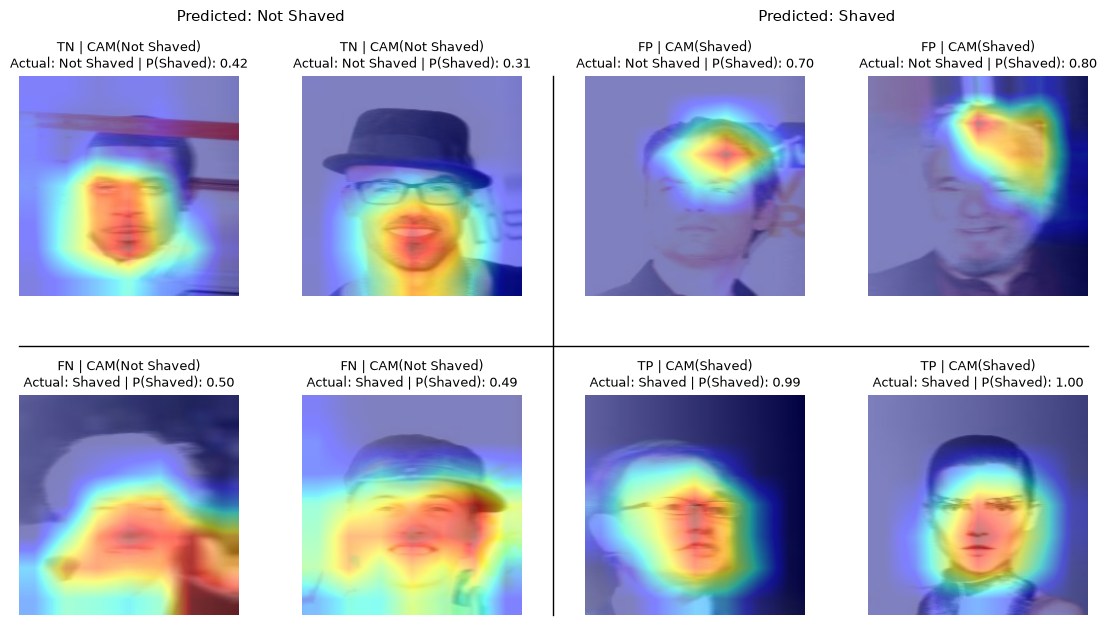

In [10]:
# Get external labels and predicted probabilities
labels=all_labels['external']
probs_shaved=all_predictions['external'][:,1]
preds=probs_shaved>=0.5

# Identify external samples by confusion matrix outcome
tn_indices=np.where((labels==0)&(preds==0))[0]
fp_indices=np.where((labels==0)&(preds==1))[0]
fn_indices=np.where((labels==1)&(preds==0))[0]
tp_indices=np.where((labels==1)&(preds==1))[0]

# Select two samples from each group
np.random.seed(10)
selected_tn=np.random.choice(tn_indices,2,replace=False)
selected_fp=np.random.choice(fp_indices,2,replace=False)
selected_fn=np.random.choice(fn_indices,2,replace=False)
selected_tp=np.random.choice(tp_indices,2,replace=False)

# Store the output of the final convolutional layer
activation={}

def get_activation(name):
    def hook(model,input,output):
        activation[name]=output.detach()
    return hook

# Capture feature maps from the final ResNet18 convolutional block
hook_handle=resnet_frozen.layer4[1].conv2.register_forward_hook(
    get_activation('resnet.layer4.1.conv2')
)

# Arrange samples as TN | FP / FN | TP
cam_groups=[
    ('TN',selected_tn),
    ('FP',selected_fp),
    ('FN',selected_fn),
    ('TP',selected_tp)
]

resnet_frozen.eval()

# TN | FP
# -------
# FN | TP
fig,axes=plt.subplots(2,4,figsize=(14,7))

with torch.no_grad():
    for result,indices in cam_groups:
        row=0 if result in ['TN','FP'] else 1
        start_col=0 if result in ['TN','FN'] else 2

        for offset,idx in enumerate(indices):
            x,y=test_external_dataset[idx]
            x=x.to(device)

            # Run inference
            output=resnet_frozen(x.unsqueeze(0))
            pred=torch.argmax(output,dim=1).item()
            prob_shaved=torch.softmax(output,dim=1)[0,1].item()

            # Get the convolutional feature maps
            conv_feature_map=activation['resnet.layer4.1.conv2'][0].detach()

            # Use classifier weights for the predicted class
            fc_weights=resnet_frozen.state_dict()['fc.weight'][pred].detach()

            # Compute the class activation map
            cam=torch.sum(fc_weights[:,None,None]*conv_feature_map,dim=0)
            cam=torch.clamp(cam,min=0)

            # Normalize CAM values to [0,1]
            if torch.max(cam)>0:
                cam=cam/torch.max(cam)

            # Resize CAM to the input image size
            cam=F.interpolate(
                cam.unsqueeze(0).unsqueeze(0),
                size=(x.shape[1],x.shape[2]),
                mode='bilinear',
                align_corners=False
            ).squeeze().cpu().numpy()

            # Reverse ImageNet normalization for visualization
            x_display=x.detach().cpu().numpy().transpose(1,2,0)*np.array(imagenet_stds)+np.array(imagenet_means)
            x_display=np.clip(x_display,0,1)

            actual='Shaved' if y==1 else 'Not Shaved'
            predicted='Shaved' if pred==1 else 'Not Shaved'

            # Plot CAM
            ax=axes[row,start_col+offset]
            ax.imshow(x_display)
            ax.imshow(cam,alpha=0.5,cmap='jet')
            ax.set_title(
                f'{result} | CAM({predicted})\n'
                f'Actual: {actual} | P(Shaved): {prob_shaved:.2f}',
                fontsize=9
            )
            ax.axis('off')

# Label actual classes
axes[0,0].set_ylabel('Actual:\nNot Shaved',fontsize=11,labelpad=10)
axes[1,0].set_ylabel('Actual:\nShaved',fontsize=11,labelpad=10)

# Label predicted classes
axes[0,0].text(
    1.1,1.25,'Predicted: Not Shaved',
    transform=axes[0,0].transAxes,
    ha='center',fontsize=11
)

axes[0,2].text(
    1.1,1.25,'Predicted: Shaved',
    transform=axes[0,2].transAxes,
    ha='center',fontsize=11
)

# Adjust spacing
plt.subplots_adjust(hspace=0.45,wspace=0.20)
fig.canvas.draw()

# Separate predicted Not Shaved and Shaved
x_mid=(axes[0,1].get_position().x1+axes[0,2].get_position().x0)/2
fig.add_artist(plt.Line2D(
    [x_mid,x_mid],
    [axes[1,0].get_position().y0,axes[0,0].get_position().y1],
    transform=fig.transFigure,color='black',linewidth=1
))

# Separate actual Not Shaved and Shaved
y_mid=(axes[0,0].get_position().y0+axes[1,0].get_position().y1)/2
fig.add_artist(plt.Line2D(
    [axes[0,0].get_position().x0,axes[0,3].get_position().x1],
    [y_mid,y_mid],
    transform=fig.transFigure,color='black',linewidth=1
))

plt.show()

# Remove the forward hook
hook_handle.remove()

The CAM analysis showed that correctly classified TN and TP samples generally produced activations over the central facial regions. In contrast, the misclassified samples showed less consistent activation patterns. In particular, the FP samples, where non-shaved faces were incorrectly predicted as shaved, showed strong activation around the upper facial region rather than the lower facial areas more directly relevant to facial hair. The FN samples also showed broader or less concentrated activation patterns. These observations suggest that the model's predictions became less reliably associated with facial regions relevant to distinguishing shaved and non-shaved faces in the external images.

>**Diagnosis:** The model appears to have learned facial-detail patterns that worked well on the studio images but became less reliable when applied to images from the mobile app, where the image-quality characteristics differed. As a result, the model was less consistent in identifying the facial regions relevant to distinguishing shaved and non-shaved faces.

>**Evidence:** Accuracy decreased substantially from 93.7% on the internal test set to 62.3% on the external test set. In particular, false positives increased from approximately 38 to 278, reducing precision for the shaved class from 0.915 to 0.574. Visual inspection showed that the internal images were generally clear and well-defined, whereas the external images seemed to be brighter and more overexposed, with some images also appearing blurred. The CAM analysis further showed that correctly classified TN and TP samples generally produced activations over relevant facial regions. In contrast, misclassified FP and FN samples showed less consistent activation patterns, with some predictions relying on upper-face or non-face regions rather than regions directly relevant to facial hair. Together, these findings suggest that the model does not generalise reliably from controlled studio-quality images to the more variable visual conditions encountered in the mobile application.

>**Recommendation:** Representative mobile images should be included during training and validation, particularly images containing variations in brightness, exposure, and blur. Corresponding data augmentation should also be applied during training, and a deployment-like validation set should be established to evaluate robustness before release. Image-quality checks or preprocessing could also be considered for severely degraded inputs. Additionally, a face-detection and landmark-based cropping step is suggested to focus the classifier on facial regions relevant to facial hair. This could reduce the model's reliance on upper-face or non-face regions, as observed in the CAM analysis.